In [50]:
import numpy as np
import xarray as xr
import tensorflow as tf
import matplotlib.pyplot as pltgbvhiko
import cartopy.crs as ccrs
import xesmf as xe
import esmpy
import os
import scipy

In [51]:
DATA_DIR = "/Volumes/FILIPOVO/ML_learning/CMIP/"
MODEL_DIR = "/Volumes/FILIPOVO/ML_learning/data/saved_models/"

tas_file   = DATA_DIR + "tas_CESM1.2-CAM5_deepmip-eocene-p1-x3_v1.0.mean.nc"
rlut_file  = DATA_DIR + "rlut_CESM1.2-CAM5_deepmip-eocene-p1-x3_v1.0.mean.nc"
rlutcs_file = DATA_DIR + "rlutcs_CESM1.2-CAM5_deepmip-eocene-p1-x3_v1.0.mean.nc"

rsut_file  = DATA_DIR + "rsut_CESM1.2-CAM5_deepmip-eocene-p1-x3_v1.0.mean.nc"
rsutcs_file = DATA_DIR + "rsutcs_CESM1.2-CAM5_deepmip-eocene-p1-x3_v1.0.mean.nc"

In [52]:
tas_ds   = xr.open_dataset(tas_file)
rlut_ds  = xr.open_dataset(rlut_file)
rlutcs_ds = xr.open_dataset(rlutcs_file)

rsut_ds  = xr.open_dataset(rsut_file)
rsutcs_ds = xr.open_dataset(rsutcs_file)

tas = tas_ds["tas"]
rlut = rlut_ds["rlut"]
rlutcs = rlutcs_ds["rlutcs"]

rsut = rsut_ds["rsut"]
rsutcs = rsutcs_ds["rsutcs"]

In [53]:
lw_cre = rlut - rlutcs
sw_cre = rsut - rsutcs

In [54]:
print(tas.shape)
print(tas.lat.size, tas.lon.size)
print(tas.lon.min(), tas.lon.max())

#expect 64 lat, 128 lon

(12, 96, 144)
96 144
<xarray.DataArray 'lon' ()> Size: 8B
array(0.)
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          degrees_east
    axis:           X <xarray.DataArray 'lon' ()> Size: 8B
array(357.5)
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          degrees_east
    axis:           X


In [55]:
lat_new = np.linspace(-90, 90, 64)
lon_new = np.linspace(0, 357.1875, 128)

tas_rg = tas.interp(lat=lat_new, lon=lon_new)
lw_cre_rg = lw_cre.interp(lat=lat_new, lon=lon_new)
sw_cre_rg = sw_cre.interp(lat=lat_new, lon=lon_new)

In [56]:
n_time = tas_rg.shape[0]

tas_input = tas_rg.values[..., np.newaxis]

print(tas_input.shape)

lw_truth = lw_cre_rg.values
sw_truth = sw_cre_rg.values

lw_model = tf.keras.models.load_model(
    MODEL_DIR + "CanESM5_rlut_rngseed0_model.keras"
)

sw_model = tf.keras.models.load_model(
    MODEL_DIR + "CanESM5_rsut_rngseed0_model.keras"
)

lw_pred = lw_model.predict(tas_input)
sw_pred = sw_model.predict(tas_input)

lw_pred = lw_pred.reshape(12, 64, 128)
sw_pred = sw_pred.reshape(12, 64, 128)

print(lw_pred.shape)
print(lw_truth.shape)

(12, 64, 128, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
(12, 64, 128)
(12, 64, 128)


In [57]:
lw_error = lw_pred - lw_truth
sw_error = sw_pred - sw_truth

lw_rmse = np.sqrt(np.nanmean(lw_error**2))
sw_rmse = np.sqrt(np.nanmean(sw_error**2))

print("LW RMSE:", lw_rmse)
print("SW RMSE:", sw_rmse)

map_shape = (64,128)

lw_error_map = np.nanmean(lw_error, axis=0)
sw_error_map = np.nanmean(sw_error, axis=0)

LW RMSE: 12.292757263662669
SW RMSE: 30.34687566675838


/Users/filipnovak/miniforge3/envs/cse160/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/filipnovak/miniforge3/envs/cse160/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/filipnovak/miniforge3/envs/cse160/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/filipnovak/miniforge3/envs/cse160/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


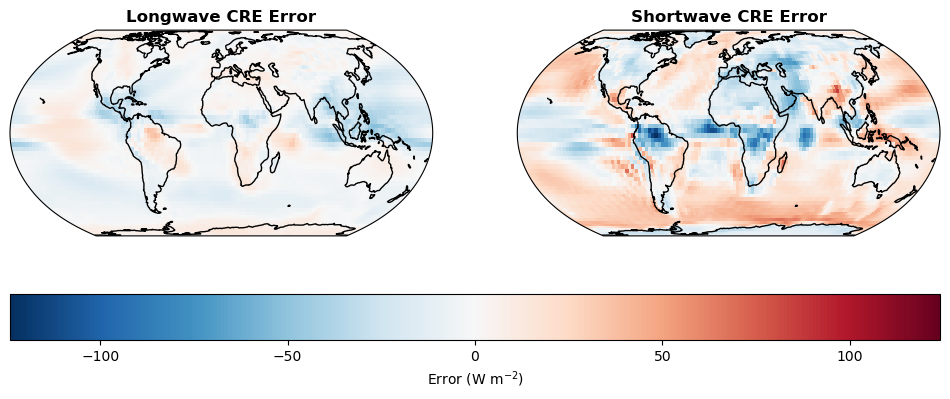

In [68]:
proj = ccrs.EqualEarth()

fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(121, projection=proj)
ax2 = fig.add_subplot(122, projection=proj)

vmax = np.nanmax(np.abs([lw_error_map, sw_error_map]))

pcm1 = ax1.pcolormesh(
    lon_new,
    lat_new,
    lw_error_map,
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
    transform=ccrs.PlateCarree(),
)

ax1.coastlines()
ax1.set_title("Longwave CRE Error", fontweight="bold")

pcm2 = ax2.pcolormesh(
    lon_new,
    lat_new,
    sw_error_map,
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
    transform=ccrs.PlateCarree(),
)

ax2.coastlines()
ax2.set_title("Shortwave CRE Error", fontweight="bold")

plt.colorbar(pcm2, ax=[ax1,ax2], orientation="horizontal", label="Error (W m$^{-2}$)")
plt.show()

/Users/filipnovak/miniforge3/envs/cse160/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/filipnovak/miniforge3/envs/cse160/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/filipnovak/miniforge3/envs/cse160/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/filipnovak/miniforge3/envs/cse160/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/filipnovak/miniforge3/envs/cse160/lib/python3.11/site-pac

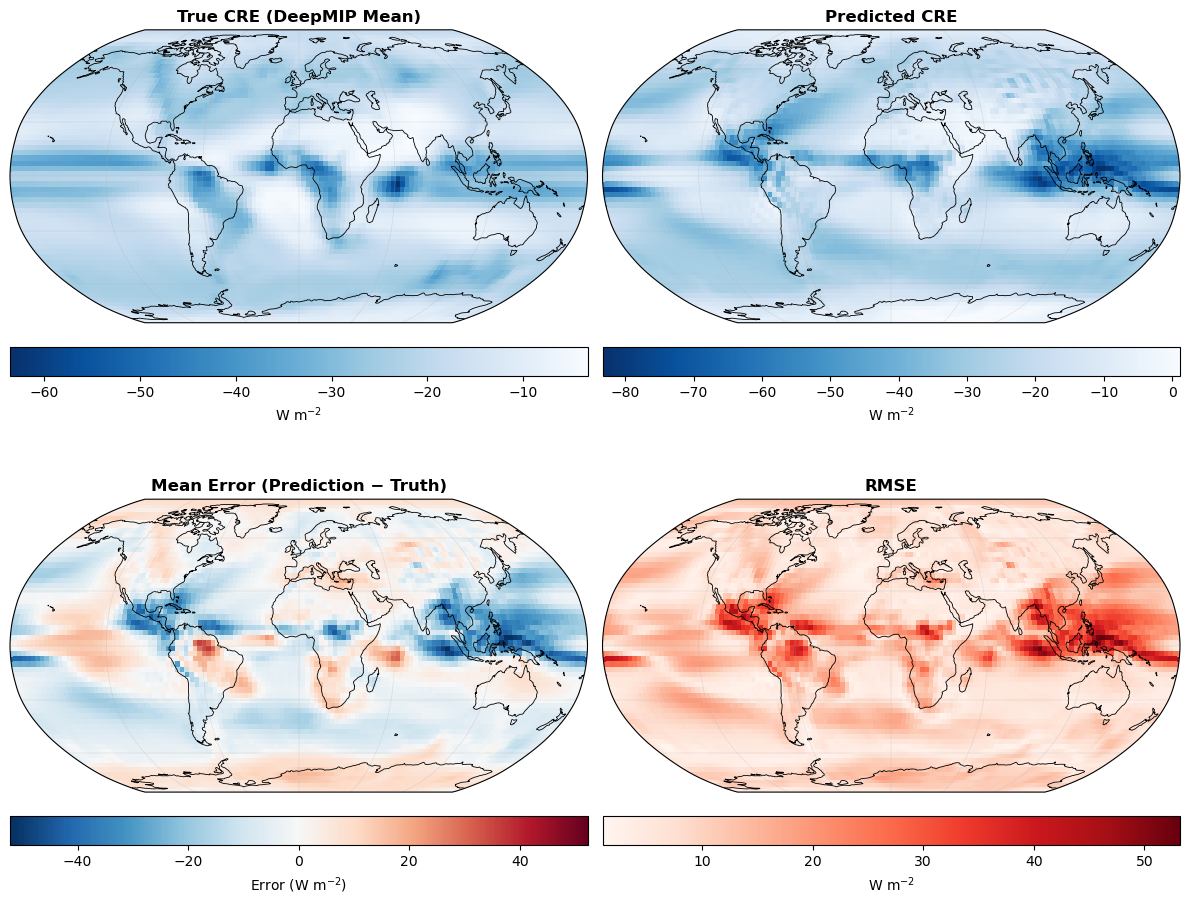

In [62]:
# ---------------------------------------
# 4-panel evaluation plot (DeepMIP test)
# ---------------------------------------

pred = lw_pred
truth = lw_truth

# Statistics
truth_mean = np.nanmean(truth, axis=0)
pred_mean  = np.nanmean(pred, axis=0)

error = pred - truth
error_mean = np.nanmean(error, axis=0)

rmse = np.sqrt(np.nanmean(error**2, axis=0))

truth_map = truth_mean
pred_map  = pred_mean
error_map = error_mean
rmse_map  = rmse

# Figure
fig, ax = plt.subplots(
    2, 2,
    figsize=(12,10),
    subplot_kw={"projection": ccrs.Robinson()}
)

# helper to format maps
def format_map(axis):
    axis.set_global()
    axis.coastlines(linewidth=0.6)
    axis.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)

# -------------------
# Panel 1 — Truth
# -------------------

im0 = ax[0,0].pcolormesh(
    lon_new, lat_new, truth_map,
    cmap="Blues_r",
    transform=ccrs.PlateCarree()
)

format_map(ax[0,0])
ax[0,0].set_title("True CRE (DeepMIP Mean)", fontweight="bold")

plt.colorbar(
    im0,
    ax=ax[0,0],
    orientation="horizontal",
    pad=0.05,
    label="W m$^{-2}$"
)

# -------------------
# Panel 2 — Prediction
# -------------------

im1 = ax[0,1].pcolormesh(
    lon_new, lat_new, pred_map,
    cmap="Blues_r",
    transform=ccrs.PlateCarree()
)

format_map(ax[0,1])
ax[0,1].set_title("Predicted CRE", fontweight="bold")

plt.colorbar(
    im1,
    ax=ax[0,1],
    orientation="horizontal",
    pad=0.05,
    label="W m$^{-2}$"
)

# -------------------
# Panel 3 — Mean error
# -------------------

vmax_err = np.nanmax(np.abs(error_map))

im2 = ax[1,0].pcolormesh(
    lon_new, lat_new,
    error_map,
    cmap="RdBu_r",
    vmin=-vmax_err,
    vmax=vmax_err,
    transform=ccrs.PlateCarree()
)

format_map(ax[1,0])
ax[1,0].set_title("Mean Error (Prediction − Truth)", fontweight="bold")

plt.colorbar(
    im2,
    ax=ax[1,0],
    orientation="horizontal",
    pad=0.05,
    label="Error (W m$^{-2}$)"
)

# -------------------
# Panel 4 — RMSE
# -------------------

im3 = ax[1,1].pcolormesh(
    lon_new, lat_new,
    rmse_map,
    cmap="Reds",
    transform=ccrs.PlateCarree()
)

format_map(ax[1,1])
ax[1,1].set_title("RMSE", fontweight="bold")

plt.colorbar(
    im3,
    ax=ax[1,1],
    orientation="horizontal",
    pad=0.05,
    label="W m$^{-2}$"
)

plt.tight_layout()
plt.show()

/Users/filipnovak/miniforge3/envs/cse160/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/filipnovak/miniforge3/envs/cse160/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/filipnovak/miniforge3/envs/cse160/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/filipnovak/miniforge3/envs/cse160/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/filipnovak/miniforge3/envs/cse160/lib/python3.11/site-pac

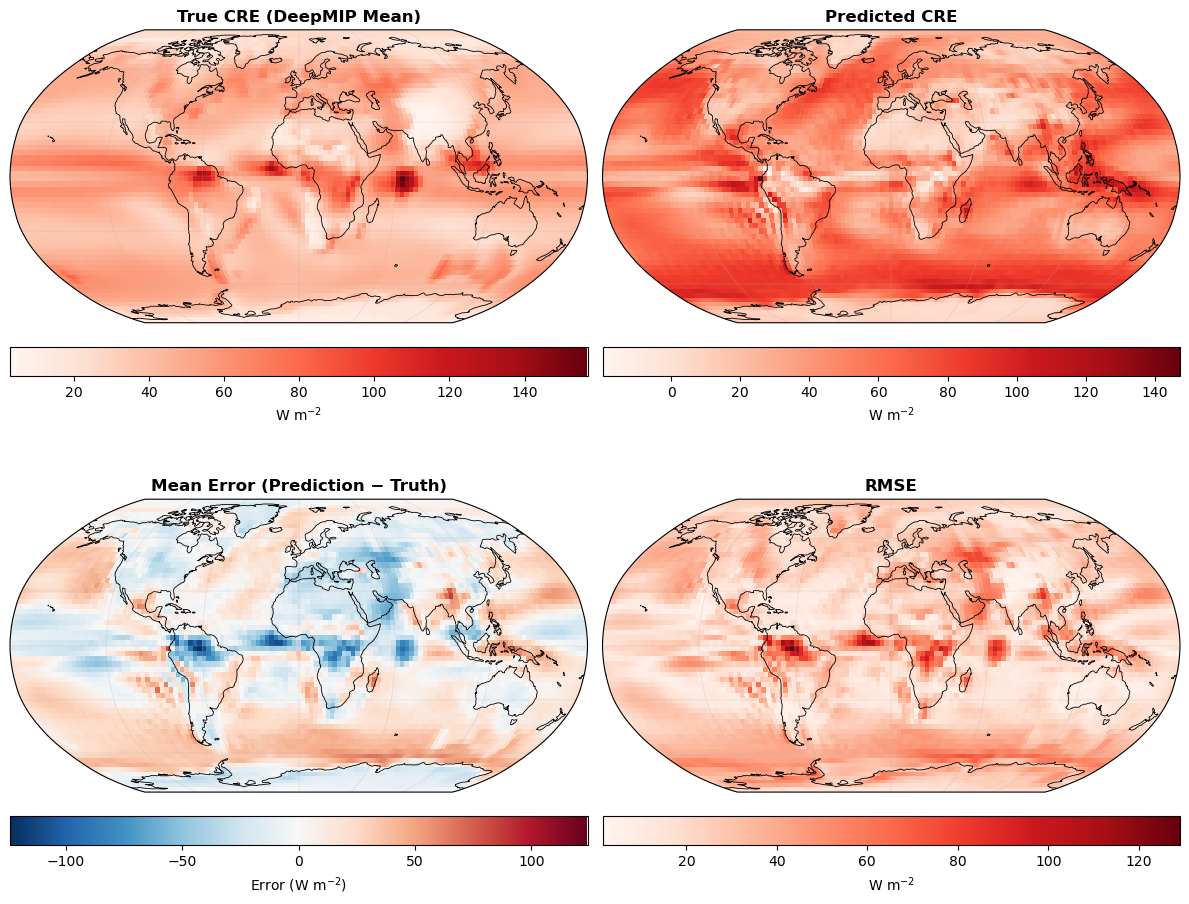

In [63]:
# ---------------------------------------
# 4-panel evaluation plot (DeepMIP test)
# ---------------------------------------

pred = sw_pred
truth = sw_truth

# Statistics
truth_mean = np.nanmean(truth, axis=0)
pred_mean  = np.nanmean(pred, axis=0)

error = pred - truth
error_mean = np.nanmean(error, axis=0)

rmse = np.sqrt(np.nanmean(error**2, axis=0))

truth_map = truth_mean
pred_map  = pred_mean
error_map = error_mean
rmse_map  = rmse

# Figure
fig, ax = plt.subplots(
    2, 2,
    figsize=(12,10),
    subplot_kw={"projection": ccrs.Robinson()}
)

# helper to format maps
def format_map(axis):
    axis.set_global()
    axis.coastlines(linewidth=0.6)
    axis.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)

# -------------------
# Panel 1 — Truth
# -------------------

im0 = ax[0,0].pcolormesh(
    lon_new, lat_new, truth_map,
    cmap="Reds",
    transform=ccrs.PlateCarree()
)

format_map(ax[0,0])
ax[0,0].set_title("True CRE (DeepMIP Mean)", fontweight="bold")

plt.colorbar(
    im0,
    ax=ax[0,0],
    orientation="horizontal",
    pad=0.05,
    label="W m$^{-2}$"
)

# -------------------
# Panel 2 — Prediction
# -------------------

im1 = ax[0,1].pcolormesh(
    lon_new, lat_new, pred_map,
    cmap="Reds",
    transform=ccrs.PlateCarree()
)

format_map(ax[0,1])
ax[0,1].set_title("Predicted CRE", fontweight="bold")

plt.colorbar(
    im1,
    ax=ax[0,1],
    orientation="horizontal",
    pad=0.05,
    label="W m$^{-2}$"
)

# -------------------
# Panel 3 — Mean error
# -------------------

vmax_err = np.nanmax(np.abs(error_map))

im2 = ax[1,0].pcolormesh(
    lon_new, lat_new,
    error_map,
    cmap="RdBu_r",
    vmin=-vmax_err,
    vmax=vmax_err,
    transform=ccrs.PlateCarree()
)

format_map(ax[1,0])
ax[1,0].set_title("Mean Error (Prediction − Truth)", fontweight="bold")

plt.colorbar(
    im2,
    ax=ax[1,0],
    orientation="horizontal",
    pad=0.05,
    label="Error (W m$^{-2}$)"
)

# -------------------
# Panel 4 — RMSE
# -------------------

im3 = ax[1,1].pcolormesh(
    lon_new, lat_new,
    rmse_map,
    cmap="Reds",
    transform=ccrs.PlateCarree()
)

format_map(ax[1,1])
ax[1,1].set_title("RMSE", fontweight="bold")

plt.colorbar(
    im3,
    ax=ax[1,1],
    orientation="horizontal",
    pad=0.05,
    label="W m$^{-2}$"
)

plt.tight_layout()
plt.show()